In [32]:
# Imports and reproducibility setup
import os, time, random, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# Keep all random operations deterministic across runs.
SEED = 12345
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [33]:
def load_pickle_image(file_path):
    """Load one MRI volume stored as a .pck file."""
    with open(file_path, "rb") as file_handle:
        return pickle.load(file_handle)


# Collect all MRI pickle files from volume folders (vol01, vol02, ...).
file_paths = []
for folder in sorted(Path("MRI_Images").iterdir()):
    if folder.is_dir() and folder.name.startswith("vol"):
        file_paths.extend(sorted(p for p in folder.iterdir() if p.suffix == ".pck"))

print(f"Found {len(file_paths)} total image files")

Found 736 total image files


In [34]:
def to_binary_label(raw_label):
    """Map original labels to binary ACL outcome (0=Normal, 1=Torn/Partial)."""
    if raw_label is None:
        return None
    return 1 if int(raw_label) == 2 else int(raw_label)


# Load metadata and build filename -> diagnosis lookup.
meta = pd.read_csv("metadata.csv")
filename_to_label = dict(zip(meta["volumeFilename"], meta["aclDiagnosis"]))
label_names = {0: "Normal", 1: "Torn"}

# Attach labels to each discovered file path.
mapped = []
for image_path in file_paths:
    label = to_binary_label(filename_to_label.get(image_path.name))
    mapped.append((image_path, label, label_names.get(label)))

# Quick class-balance summary for sanity checking.
label_counts = Counter(l for _p, l, _n in mapped if l is not None)
label_name_counts = Counter(n for _p, l, n in mapped if n is not None)
print(f"Mapped {sum(label_counts.values())} labeled scans")
print(f"Class counts: {dict(label_name_counts)}")

Mapped 736 labeled scans
Class counts: {'Normal': 547, 'Torn': 189}


In [35]:
# ---------- Preprocessing + classical (HOG + linear) models ----------
MAX_SAMPLES = 400
IMG_SIZE = (64, 64)
hog_params = {"orientations": 9, "pixels_per_cell": (8, 8), "cells_per_block": (2, 2)}


def prepare_volume_inputs(volume, image_size):
    """
    Convert one MRI volume into:
    1) A single grayscale slice for HOG
    2) A 3-channel image tensor for CNN input
    """
    volume_arr = np.asarray(volume)

    # Preferred path: use center slice +/- 1 to form a 3-channel stack.
    if volume_arr.ndim == 3 and volume_arr.shape[0] >= 3:
        center_idx = volume_arr.shape[0] // 2
        slice_indices = [
            max(0, center_idx - 1),
            center_idx,
            min(volume_arr.shape[0] - 1, center_idx + 1),
        ]
        channels = []
        for slice_index in slice_indices:
            slice_image = volume_arr[slice_index]
            if slice_image.ndim == 3:
                slice_image = rgb2gray(slice_image)
            slice_resized = resize(slice_image, image_size, anti_aliasing=True)
            channels.append(slice_resized.astype(np.float32))
        return channels[1], np.stack(channels, axis=-1)

    # Fallback path: repeat one center slice across 3 channels.
    center_slice = volume_arr[volume_arr.shape[0] // 2] if volume_arr.ndim == 3 else volume_arr
    if center_slice.ndim == 3:
        center_slice = rgb2gray(center_slice)
    center_slice = resize(center_slice, image_size, anti_aliasing=True)
    return center_slice, np.stack([center_slice.astype(np.float32)] * 3, axis=-1)


# Group file paths by class label.
paths_by_label = {}
for file_path, label, _name in mapped:
    if label is None:
        continue
    paths_by_label.setdefault(label, []).append(file_path)

class_labels = sorted(paths_by_label.keys())
num_classes = len(class_labels)
print("Detected classes:", class_labels)

# Aim for class-balanced sampling under MAX_SAMPLES total.
samples_per_class_target = max(1, MAX_SAMPLES // max(1, num_classes))

# Use cached preprocessed arrays when available to save time.
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)
cache_path = cache_dir / "preprocessed.npz"
rng = random.Random(SEED)

if cache_path.exists():
    print("Loading preprocessed data from", cache_path)
    data = np.load(cache_path, allow_pickle=True)
    X_hog = data["X_hog"]
    X_images = data["X_images"]
    y_labels = data["y_labels"]
else:
    hog_features_list = []
    image_tensors_list = []
    labels_list = []
    t_start = time.time()

    for label in class_labels:
        file_paths_for_label = paths_by_label[label]
        if len(file_paths_for_label) == 0:
            continue

        # Deterministic per-class sampling.
        n_take = min(len(file_paths_for_label), samples_per_class_target)
        chosen = rng.sample(list(file_paths_for_label), n_take)

        for chosen_path in chosen:
            volume = load_pickle_image(chosen_path)
            slice_resized, cnn_img = prepare_volume_inputs(volume, IMG_SIZE)

            # HOG features from the center grayscale slice.
            hog_descriptor = hog(
                (slice_resized * 255).astype(np.uint8),
                orientations=hog_params["orientations"],
                pixels_per_cell=hog_params["pixels_per_cell"],
                cells_per_block=hog_params["cells_per_block"],
                visualize=False,
                feature_vector=True,
            )
            hog_features_list.append(hog_descriptor)

            # CNN tensor from 3-channel representation.
            image_tensors_list.append(cnn_img)
            labels_list.append(label)

    t_end = time.time()
    print(f"Preprocessing done: {len(hog_features_list)} items in {t_end - t_start:.1f}s")

    # Enforce MAX_SAMPLES deterministically.
    if len(hog_features_list) > MAX_SAMPLES:
        hog_features_list = hog_features_list[:MAX_SAMPLES]
        image_tensors_list = image_tensors_list[:MAX_SAMPLES]
        labels_list = labels_list[:MAX_SAMPLES]

    X_hog = np.vstack(hog_features_list)
    y_labels = np.array(labels_list)
    X_images = np.stack(image_tensors_list)

    np.savez_compressed(cache_path, X_hog=X_hog, X_images=X_images, y_labels=y_labels)
    print("Saved preprocessed cache to", cache_path)

print("Unique labels in dataset:", np.unique(y_labels))

# One reproducible split reused by all models.
X_hog_train, X_hog_test, y_hog_train, y_hog_test = train_test_split(
    X_hog,
    y_labels,
    test_size=0.2,
    stratify=y_labels,
    random_state=SEED,
)
idx_all = np.arange(len(y_labels))
_, idx_test = train_test_split(
    idx_all,
    test_size=0.2,
    stratify=y_labels,
    random_state=SEED,
)
idx_train = np.setdiff1d(idx_all, idx_test)
X_images_train = X_images[idx_train]
X_images_val = X_images[idx_test]
y_images_train = y_labels[idx_train]
y_images_val = y_labels[idx_test]

# Baseline classical models on HOG features.
epochs = 10
sgd_svm = SGDClassifier(loss="hinge", random_state=SEED)
for _ in range(epochs):
    sgd_svm.partial_fit(X_hog_train, y_hog_train, classes=np.unique(y_hog_train))

sgd_logr = SGDClassifier(loss="log_loss", random_state=SEED)
for _ in range(epochs):
    sgd_logr.partial_fit(X_hog_train, y_hog_train, classes=np.unique(y_hog_train))

print("SGD-SVM acc:", accuracy_score(y_hog_test, sgd_svm.predict(X_hog_test)))
print("SGD-LogReg acc:", accuracy_score(y_hog_test, sgd_logr.predict(X_hog_test)))

labels_sorted = sorted(np.unique(y_hog_test))
label_names_for_report = [label_names.get(int(i), str(int(i))) for i in labels_sorted]
print("\nSGD-SVM classification report:\n")
print(classification_report(y_hog_test, sgd_svm.predict(X_hog_test), labels=labels_sorted, target_names=label_names_for_report))
print("\nSGD-LogReg classification report:\n")
print(classification_report(y_hog_test, sgd_logr.predict(X_hog_test), labels=labels_sorted, target_names=label_names_for_report))

Detected classes: [0, 1]
Loading preprocessed data from cache/preprocessed.npz
Unique labels in dataset: [0 1]
SGD-SVM acc: 0.5769230769230769
SGD-LogReg acc: 0.5769230769230769

SGD-SVM classification report:

              precision    recall  f1-score   support

      Normal       0.61      0.50      0.55        40
        Torn       0.56      0.66      0.60        38

    accuracy                           0.58        78
   macro avg       0.58      0.58      0.58        78
weighted avg       0.58      0.58      0.57        78


SGD-LogReg classification report:

              precision    recall  f1-score   support

      Normal       0.56      0.78      0.65        40
        Torn       0.61      0.37      0.46        38

    accuracy                           0.58        78
   macro avg       0.59      0.57      0.56        78
weighted avg       0.59      0.58      0.56        78



In [ ]:
# ---------- CNN model training + evaluation ----------
# Keep pixel values in [0, 1] for stable CNN optimization.
X_images_train = np.clip(X_images_train, 0.0, 1.0)
X_images_val = np.clip(X_images_val, 0.0, 1.0)

# Class balance in the image training split.
unique, counts = np.unique(y_images_train, return_counts=True)
print("Image-train class counts:", dict(zip(unique.astype(int).tolist(), counts.tolist())))

# No explicit class weighting in this run.
class_weight_dict = None

n_classes = 2
model = models.Sequential([
    layers.Input(shape=X_images_train.shape[1:]),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax"),
])

opt = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("\nTraining CNN...")
history = model.fit(
    X_images_train,
    y_images_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_images_val, y_images_val),
    verbose=2,
    class_weight=class_weight_dict,
)

loss, acc = model.evaluate(X_images_val, y_images_val, verbose=0)
print("\nCNN validation acc:", acc)

# Validation-set predictions and report.
y_pred_cnn = np.argmax(model.predict(X_images_val), axis=1)
labels_sorted_img = sorted(np.unique(y_images_val))
label_names_for_report_img = [label_names.get(int(i), str(int(i))) for i in labels_sorted_img]
print("\nCNN classification report:\n")
print(classification_report(y_images_val, y_pred_cnn, labels=labels_sorted_img, target_names=label_names_for_report_img))

# Confusion matrix for error inspection.
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_images_val, y_pred_cnn, labels=labels_sorted_img)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

Image-train class counts: {0: 160, 1: 151}

Training CNN (no early stopping, denser model)...
Epoch 1/100
20/20 - 2s - 84ms/step - accuracy: 0.4791 - loss: 1.0214 - val_accuracy: 0.5128 - val_loss: 0.6929
Epoch 2/100
20/20 - 0s - 19ms/step - accuracy: 0.5370 - loss: 1.0284 - val_accuracy: 0.5128 - val_loss: 0.6928
Epoch 3/100
20/20 - 0s - 19ms/step - accuracy: 0.4952 - loss: 0.9221 - val_accuracy: 0.5128 - val_loss: 0.6928
Epoch 4/100
20/20 - 0s - 19ms/step - accuracy: 0.5434 - loss: 0.9773 - val_accuracy: 0.5128 - val_loss: 0.6928
Epoch 5/100
20/20 - 0s - 20ms/step - accuracy: 0.5820 - loss: 0.9314 - val_accuracy: 0.5128 - val_loss: 0.6928
Epoch 6/100
20/20 - 0s - 19ms/step - accuracy: 0.6141 - loss: 0.8781 - val_accuracy: 0.5128 - val_loss: 0.6929
Epoch 7/100
20/20 - 0s - 18ms/step - accuracy: 0.5466 - loss: 0.8959 - val_accuracy: 0.5128 - val_loss: 0.6928
Epoch 8/100
20/20 - 0s - 18ms/step - accuracy: 0.5756 - loss: 0.8189 - val_accuracy: 0.5128 - val_loss: 0.6934
Epoch 9/100
20/20 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Model comparison:
     model  accuracy  precision   recall  f1_score
   SGD-SVM  0.576923   0.555556 0.657895  0.602410
SGD-LogReg  0.576923   0.608696 0.368421  0.459016
       CNN  0.602564   0.666667 0.368421  0.474576


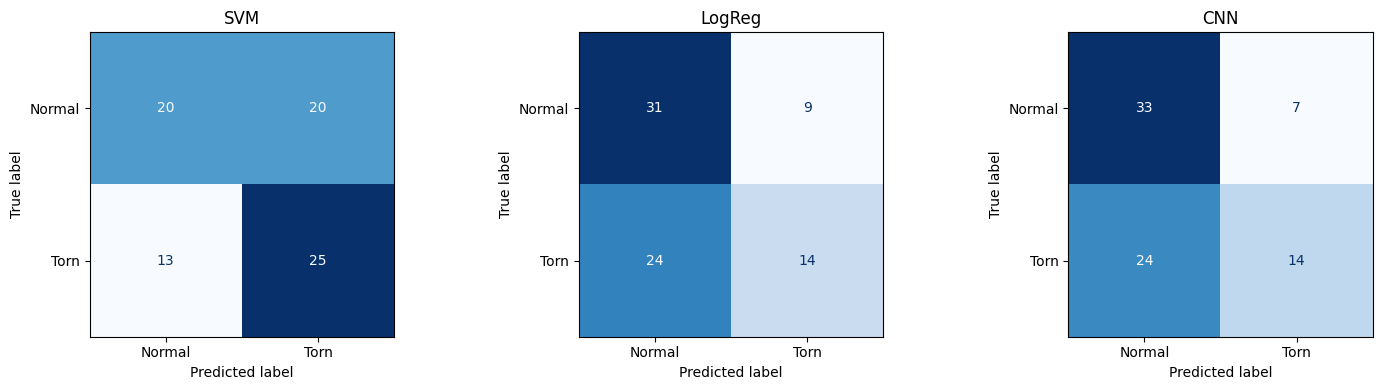

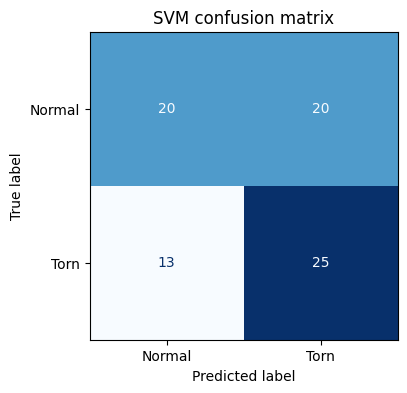

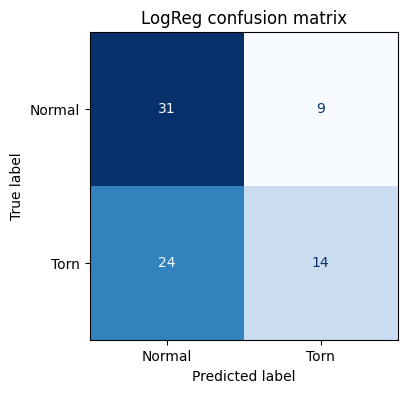

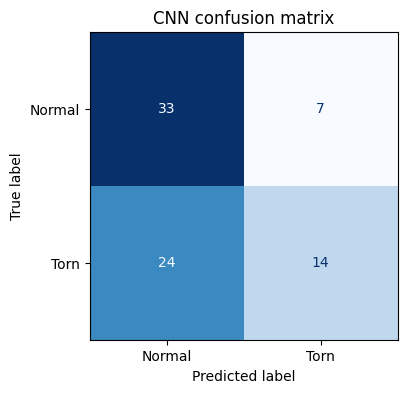

In [ ]:
# ---------- Unified model comparison ----------
# Collect predictions from all three trained models.
y_pred_svm = sgd_svm.predict(X_hog_test)
y_pred_logr = sgd_logr.predict(X_hog_test)
y_pred_cnn = np.argmax(model.predict(X_images_val), axis=1)


def _metrics(y_true, y_pred):
    """Return accuracy, precision, recall, and F1 for binary labels."""
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return acc, prec, rec, f1


acc_svm, prec_svm, rec_svm, f1_svm = _metrics(y_hog_test, y_pred_svm)
acc_logr, prec_logr, rec_logr, f1_logr = _metrics(y_hog_test, y_pred_logr)
acc_cnn, prec_cnn, rec_cnn, f1_cnn = _metrics(y_images_val, y_pred_cnn)

# Tabular summary for quick side-by-side comparison.
results_df = pd.DataFrame({
    "model": ["SGD-SVM", "SGD-LogReg", "CNN"],
    "accuracy": [acc_svm, acc_logr, acc_cnn],
    "precision": [prec_svm, prec_logr, prec_cnn],
    "recall": [rec_svm, rec_logr, rec_cnn],
    "f1_score": [f1_svm, f1_logr, f1_cnn],
})
print("\nModel comparison:")
print(results_df.to_string(index=False))

# Compare confusion matrices in a single figure.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ("SVM", y_hog_test, y_pred_svm),
    ("LogReg", y_hog_test, y_pred_logr),
    ("CNN", y_images_val, y_pred_cnn),
]
for ax, (name, y_true, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[0], label_names[1]])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()

# Also show each matrix individually for easier inspection.
models_info_for_plot = [
    ("SVM", y_hog_test, y_pred_svm),
    ("LogReg", y_hog_test, y_pred_logr),
    ("CNN", y_images_val, y_pred_cnn),
]
for name, y_true, y_pred in models_info_for_plot:
    cm_single = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig_single, ax_single = plt.subplots(figsize=(4, 4))
    disp_single = ConfusionMatrixDisplay(confusion_matrix=cm_single, display_labels=[label_names[0], label_names[1]])
    disp_single.plot(ax=ax_single, cmap="Blues", colorbar=False)
    ax_single.set_title(f"{name} confusion matrix")
    plt.show()